# 前処理結果の検証・可視化

このノートブックでは、前処理パイプラインの出力結果を検証し、可視化を行います。

## 検証内容
1. 前処理済みデータの基本統計
2. データ形状とサイズの確認
3. センサーデータの可視化
4. 人口統計データの分析
5. ラベル分布の確認
6. 正規化の効果確認
7. ToFセンサーデータの可視化


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("必要なライブラリのインポート完了")


必要なライブラリのインポート完了


## 1. 前処理済みデータの読み込み


In [2]:
# 前処理済みデータのパス
experiment_name = "20250713_preproc_pipeline_first_try"
data_dir = Path(f"../output/experiments/{experiment_name}/preprocessed")

print(f"データディレクトリ: {data_dir}")
print(f"存在確認: {data_dir.exists()}")

# ファイル一覧表示
if data_dir.exists():
    files = list(data_dir.glob("*.pkl"))
    print(f"\n前処理済みファイル数: {len(files)}")
    for file in sorted(files):
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"  {file.name}: {size_mb:.2f} MB")
else:
    print("❌ データディレクトリが見つかりません")


データディレクトリ: ../output/experiments/20250713_preproc_pipeline_first_try/preprocessed
存在確認: True

前処理済みファイル数: 13
  preprocessor.pkl: 0.00 MB
  test_demographics.pkl: 0.00 MB
  test_info.pkl: 0.00 MB
  test_labels.pkl: 0.00 MB
  test_tabular.pkl: 0.00 MB
  test_tof_windows.pkl: 0.13 MB
  test_windows.pkl: 0.01 MB
  train_demographics.pkl: 0.22 MB
  train_info.pkl: 0.29 MB
  train_labels.pkl: 1.34 MB
  train_tabular.pkl: 8.21 MB
  train_tof_windows.pkl: 701.84 MB
  train_windows.pkl: 48.88 MB


In [3]:
# データ読み込み関数
def load_pickle(filename):
    """pickleファイルを読み込む"""
    filepath = data_dir / filename
    if filepath.exists():
        with open(filepath, 'rb') as f:
            return pickle.load(f)
    else:
        print(f"❌ ファイルが見つかりません: {filename}")
        return None

# 学習データの読み込み
print("=== 学習データの読み込み ===")
train_windows = load_pickle("train_windows.pkl")
train_demographics = load_pickle("train_demographics.pkl")
train_tabular = load_pickle("train_tabular.pkl")
train_tof_voxel = load_pickle("train_tof_windows.pkl")
train_labels = load_pickle("train_labels.pkl")
train_info = load_pickle("train_info.pkl")

# テストデータの読み込み
print("\n=== テストデータの読み込み ===")
test_windows = load_pickle("test_windows.pkl")
test_demographics = load_pickle("test_demographics.pkl")
test_tabular = load_pickle("test_tabular.pkl")
test_tof_voxel = load_pickle("test_tof_windows.pkl")
test_labels = load_pickle("test_labels.pkl")
test_info = load_pickle("test_info.pkl")

# 前処理器の読み込み
print("\n=== 前処理器の読み込み ===")
preprocessor = load_pickle("preprocessor.pkl")

print("\n✅ 全てのデータの読み込み完了")


=== 学習データの読み込み ===

=== テストデータの読み込み ===

=== 前処理器の読み込み ===

✅ 全てのデータの読み込み完了


## 2. データ形状とサイズの確認


In [4]:
# データ形状の確認
print("=== データ形状の確認 ===")
print("\n【学習データ】")
print(f"  Windows (センサー): {train_windows.shape if train_windows is not None else 'None'}")
print(f"  Demographics: {train_demographics.shape if train_demographics is not None else 'None'}")
print(f"  Tabular: {train_tabular.shape if train_tabular is not None else 'None'}")
print(f"  ToF Voxel: {train_tof_voxel.shape if train_tof_voxel is not None else 'None'}")
print(f"  Labels: {train_labels.shape if train_labels is not None else 'None'}")
print(f"  Info: {len(train_info) if train_info is not None else 'None'}")

print("\n【テストデータ】")
print(f"  Windows (センサー): {test_windows.shape if test_windows is not None else 'None'}")
print(f"  Demographics: {test_demographics.shape if test_demographics is not None else 'None'}")
print(f"  Tabular: {test_tabular.shape if test_tabular is not None else 'None'}")
print(f"  ToF Voxel: {test_tof_voxel.shape if test_tof_voxel is not None else 'None'}")
print(f"  Labels: {test_labels.shape if test_labels is not None else 'None'}")
print(f"  Info: {len(test_info) if test_info is not None else 'None'}")

# データタイプの確認
print("\n=== データタイプの確認 ===")
if train_windows is not None:
    print(f"Train Windows dtype: {train_windows.dtype}")
if train_demographics is not None:
    print(f"Train Demographics dtype: {train_demographics.dtype}")
if train_tabular is not None:
    print(f"Train Tabular dtype: {train_tabular.dtype}")
if train_labels is not None:
    print(f"Train Labels dtype: {train_labels.dtype}")


=== データ形状の確認 ===

【学習データ】
  Windows (センサー): (8343, 128, 12)
  Demographics: (8343, 7)
  Tabular: (8343, 129)
  ToF Voxel: (574945, 5, 8, 8)
  Labels: (8343,)
  Info: 8343

【テストデータ】
  Windows (センサー): (2, 128, 12)
  Demographics: (2, 7)
  Tabular: (2, 129)
  ToF Voxel: (107, 5, 8, 8)
  Labels: (2,)
  Info: 2

=== データタイプの確認 ===
Train Windows dtype: float32
Train Demographics dtype: float32
Train Tabular dtype: float64
Train Labels dtype: <U42


## 3. ラベル分布の確認


=== ラベル分布の確認 ===

学習データのラベル数: 18
総ウィンドウ数: 8343

【ラベル分布】
                                         Label  Count  Percentage
10                              Neck - scratch    735    8.809781
14                               Text on phone    672    8.054657
3                          Eyebrow - pull hair    657    7.874865
7                           Forehead - scratch    643    7.707060
9                            Neck - pinch skin    642    7.695074
1                           Cheek - pinch skin    642    7.695074
4                          Eyelash - pull hair    641    7.683088
6                     Forehead - pull hairline    640    7.671102
0                        Above ear - pull hair    638    7.647129
16                           Write name in air    482    5.777298
15                                  Wave hello    481    5.765312
12                   Pull air toward your face    477    5.717368
5   Feel around in tray and pull out an object    179    2.145511
8                   

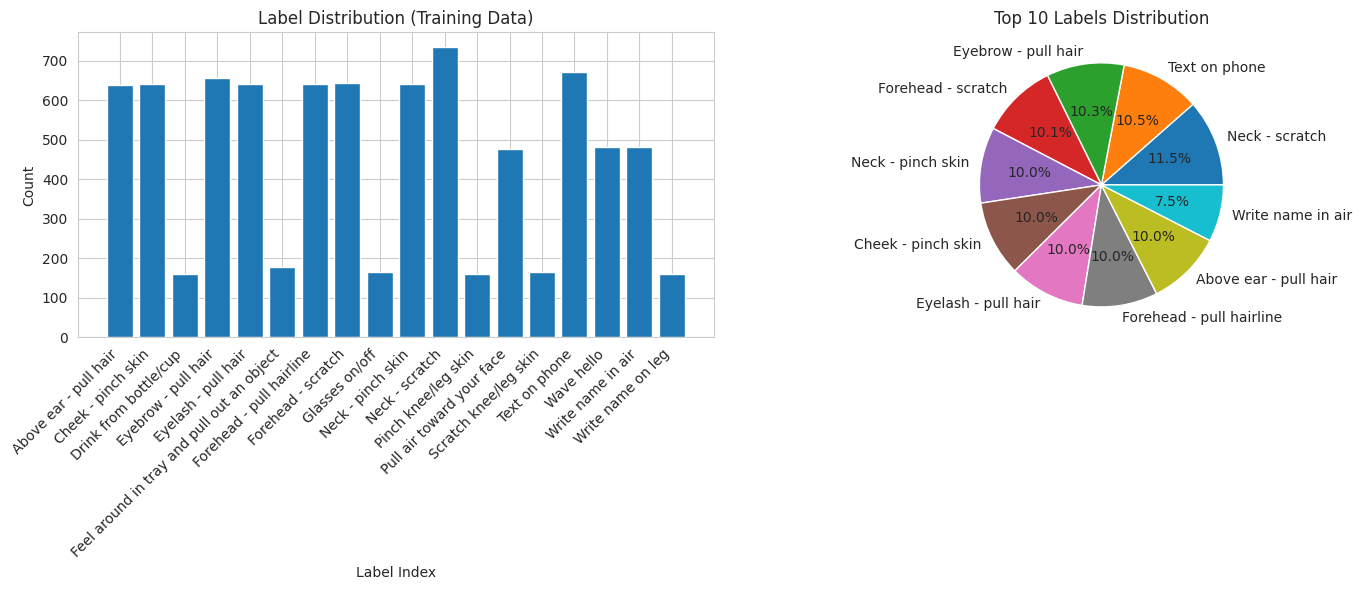


テストデータのラベル: [-1]
テストデータのラベル数: 1
✅ テストデータには予想通りプレースホルダー(-1)が設定されています


In [5]:
# ラベル分布の分析
if train_labels is not None:
    print("=== ラベル分布の確認 ===")
    
    # 学習データのラベル分布
    unique_labels, counts = np.unique(train_labels, return_counts=True)
    print(f"\n学習データのラベル数: {len(unique_labels)}")
    print(f"総ウィンドウ数: {len(train_labels)}")
    
    # ラベル分布の詳細
    label_df = pd.DataFrame({
        'Label': unique_labels,
        'Count': counts,
        'Percentage': counts / len(train_labels) * 100
    })
    label_df = label_df.sort_values('Count', ascending=False)
    print("\n【ラベル分布】")
    print(label_df)
    
    # 可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 棒グラフ
    ax1.bar(range(len(unique_labels)), counts)
    ax1.set_xlabel('Label Index')
    ax1.set_ylabel('Count')
    ax1.set_title('Label Distribution (Training Data)')
    ax1.set_xticks(range(len(unique_labels)))
    ax1.set_xticklabels(unique_labels, rotation=45, ha='right')
    
    # 円グラフ（上位10個のみ）
    top_10 = label_df.head(10)
    ax2.pie(top_10['Count'], labels=top_10['Label'], autopct='%1.1f%%')
    ax2.set_title('Top 10 Labels Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # テストデータのラベル確認
    if test_labels is not None:
        print(f"\nテストデータのラベル: {np.unique(test_labels)}")
        print(f"テストデータのラベル数: {len(np.unique(test_labels))}")
        if -1 in test_labels:
            print("✅ テストデータには予想通りプレースホルダー(-1)が設定されています")
else:
    print("❌ ラベルデータが読み込まれていません")


## 4. センサーウィンドウデータの分析


=== センサーウィンドウデータの分析 ===

ウィンドウ数: 8343
ウィンドウサイズ: 128
特徴量数: 12

【基本統計】
平均値: 0.000000
標準偏差: 0.999999
最小値: -8.216621
最大値: 8.660789

【データ品質】
NaN値の数: 0
Inf値の数: 0

=== ランダムウィンドウの可視化 ===


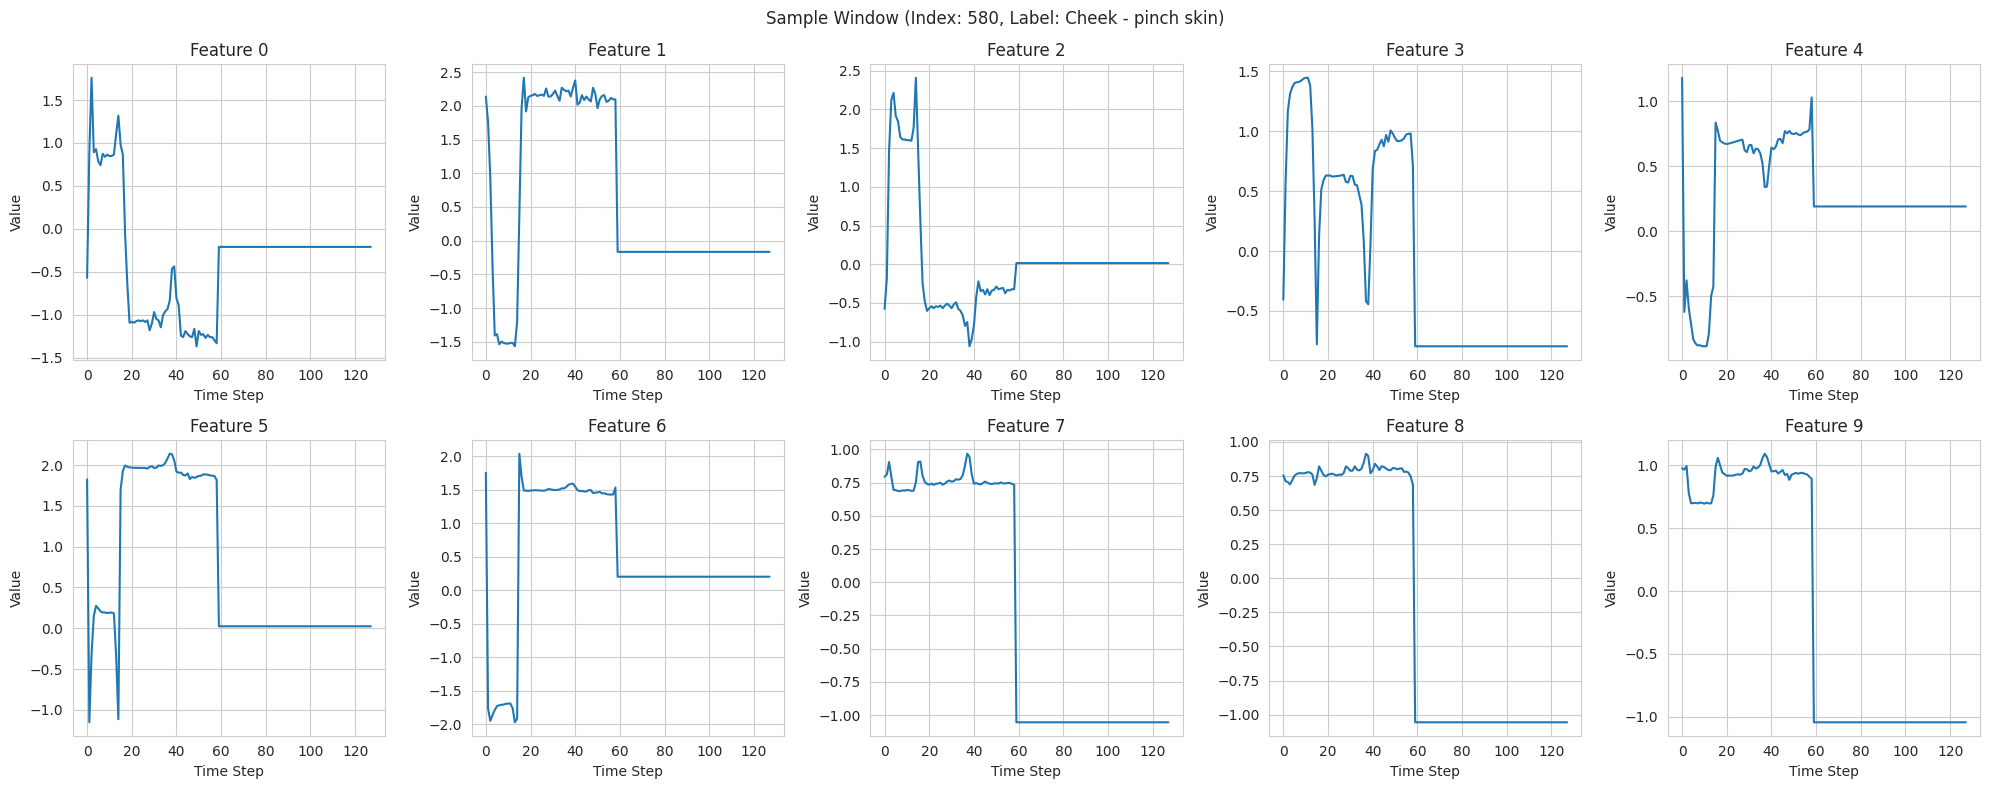

In [6]:
# センサーウィンドウデータの分析
if train_windows is not None:
    print("=== センサーウィンドウデータの分析 ===")
    
    n_windows, window_size, n_features = train_windows.shape
    print(f"\nウィンドウ数: {n_windows}")
    print(f"ウィンドウサイズ: {window_size}")
    print(f"特徴量数: {n_features}")
    
    # 基本統計
    print(f"\n【基本統計】")
    print(f"平均値: {train_windows.mean():.6f}")
    print(f"標準偏差: {train_windows.std():.6f}")
    print(f"最小値: {train_windows.min():.6f}")
    print(f"最大値: {train_windows.max():.6f}")
    
    # 欠損値・異常値の確認
    nan_count = np.isnan(train_windows).sum()
    inf_count = np.isinf(train_windows).sum()
    print(f"\n【データ品質】")
    print(f"NaN値の数: {nan_count}")
    print(f"Inf値の数: {inf_count}")
    
    # ランダムなウィンドウの可視化
    print("\n=== ランダムウィンドウの可視化 ===")
    random_idx = np.random.randint(0, n_windows)
    sample_window = train_windows[random_idx]
    sample_label = train_labels[random_idx] if train_labels is not None else "Unknown"
    
    # 最初の10個の特徴量を可視化
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i in range(min(10, n_features)):
        axes[i].plot(sample_window[:, i])
        axes[i].set_title(f'Feature {i}')
        axes[i].set_xlabel('Time Step')
        axes[i].set_ylabel('Value')
        axes[i].grid(True)
    
    plt.suptitle(f'Sample Window (Index: {random_idx}, Label: {sample_label})')
    plt.tight_layout()
    plt.show()
else:
    print("❌ センサーウィンドウデータが読み込まれていません")


## 5. 総合評価とまとめ


In [7]:
# 総合評価とまとめ
print("=== 前処理パイプラインの総合評価 ===")

# チェックリスト
checks = {
    "データ読み込み": True,
    "センサーデータ形状": train_windows is not None and len(train_windows.shape) == 3,
    "人口統計データ形状": train_demographics is not None and len(train_demographics.shape) == 2,
    "表形式特徴量形状": train_tabular is not None and len(train_tabular.shape) == 2,
    "ToFデータ形状": train_tof_voxel is not None,
    "ラベルデータ": train_labels is not None,
    "テストデータ存在": test_windows is not None and test_demographics is not None,
    "前処理器保存": preprocessor is not None,
}

# 正規化チェック
if train_windows is not None:
    feature_means = train_windows.mean(axis=(0, 1))
    feature_stds = train_windows.std(axis=(0, 1))
    checks["センサーデータ正規化"] = (np.abs(feature_means) < 1e-2).all() and (np.abs(feature_stds - 1.0) < 1e-2).all()

if train_tabular is not None:
    tab_means = train_tabular.mean(axis=0)
    tab_stds = train_tabular.std(axis=0)
    checks["表形式特徴量正規化"] = (np.abs(tab_means) < 1e-2).all() and (np.abs(tab_stds - 1.0) < 1e-2).all()

if train_demographics is not None:
    demo_means = train_demographics.mean(axis=0)
    demo_stds = train_demographics.std(axis=0)
    checks["人口統計データ正規化"] = (np.abs(demo_means) < 1e-2).all() and (np.abs(demo_stds - 1.0) < 1e-2).all()

# 欠損値チェック
if train_windows is not None:
    checks["センサーデータ欠損値なし"] = not np.isnan(train_windows).any()
if train_demographics is not None:
    checks["人口統計データ欠損値なし"] = not np.isnan(train_demographics).any()
if train_tabular is not None:
    checks["表形式特徴量欠損値なし"] = not np.isnan(train_tabular).any()

# 結果表示
print("\n【チェック結果】")
passed = 0
total = len(checks)

for check_name, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"  {check_name}: {status}")
    if result:
        passed += 1

print(f"\n【総合評価】")
print(f"合格率: {passed}/{total} ({passed/total*100:.1f}%)")

if passed == total:
    print("\n🎉 前処理パイプラインは正常に動作しています！")
    print("   モデル学習に進むことができます。")
elif passed >= total * 0.8:
    print("\n⚠️ 前処理パイプラインは概ね正常ですが、いくつかの問題があります。")
    print("   問題を確認して修正することをお勧めします。")
else:
    print("\n❌ 前処理パイプラインに重大な問題があります。")
    print("   問題を修正してから次のステップに進んでください。")

# データサマリー
print("\n【データサマリー】")
if train_windows is not None:
    print(f"  学習ウィンドウ数: {train_windows.shape[0]:,}")
    print(f"  ウィンドウサイズ: {train_windows.shape[1]}")
    print(f"  センサー特徴量数: {train_windows.shape[2]}")
if train_demographics is not None:
    print(f"  人口統計特徴量数: {train_demographics.shape[1]}")
if train_tabular is not None:
    print(f"  表形式特徴量数: {train_tabular.shape[1]}")
if train_labels is not None:
    unique_labels = np.unique(train_labels)
    print(f"  ラベル数: {len(unique_labels)}")
if test_windows is not None:
    print(f"  テストウィンドウ数: {test_windows.shape[0]:,}")

print("\n前処理結果の検証が完了しました。")


=== 前処理パイプラインの総合評価 ===

【チェック結果】
  データ読み込み: ✅ PASS
  センサーデータ形状: ✅ PASS
  人口統計データ形状: ✅ PASS
  表形式特徴量形状: ✅ PASS
  ToFデータ形状: ✅ PASS
  ラベルデータ: ✅ PASS
  テストデータ存在: ✅ PASS
  前処理器保存: ✅ PASS
  センサーデータ正規化: ✅ PASS
  表形式特徴量正規化: ✅ PASS
  人口統計データ正規化: ✅ PASS
  センサーデータ欠損値なし: ✅ PASS
  人口統計データ欠損値なし: ✅ PASS
  表形式特徴量欠損値なし: ✅ PASS

【総合評価】
合格率: 14/14 (100.0%)

🎉 前処理パイプラインは正常に動作しています！
   モデル学習に進むことができます。

【データサマリー】
  学習ウィンドウ数: 8,343
  ウィンドウサイズ: 128
  センサー特徴量数: 12
  人口統計特徴量数: 7
  表形式特徴量数: 129
  ラベル数: 18
  テストウィンドウ数: 2

前処理結果の検証が完了しました。


## 1. 生データと前処理後データの比較可視化（サンプリング）


Sample sequence_id: SEQ_025044, subject: SUBJ_059960


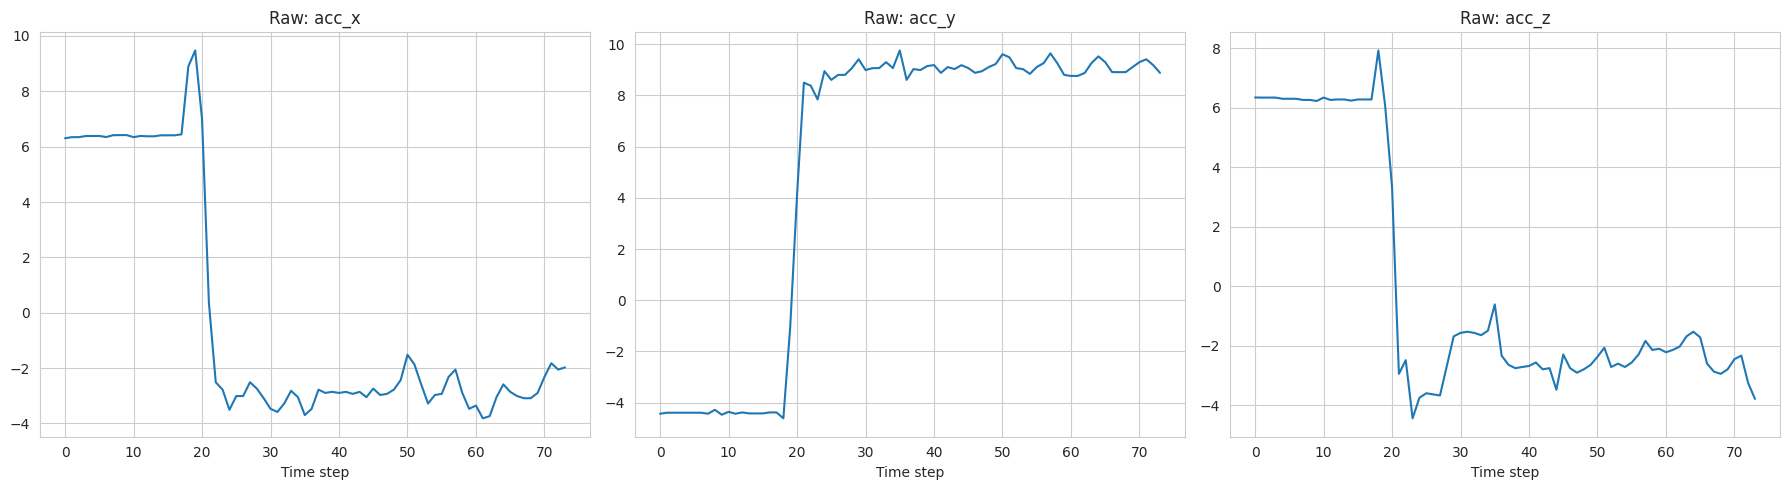

In [8]:
import pandas as pd

# サンプル対象のsubject, sequence_idをランダムに選ぶ
raw_df = pd.read_csv('../data/train.csv')
demo_df = pd.read_csv('../data/train_demographics.csv')
raw_df = raw_df.merge(demo_df, on='subject', how='left')

# サンプル選択
sample_seq = raw_df['sequence_id'].sample(1).values[0]
sample_raw = raw_df[raw_df['sequence_id'] == sample_seq]

print(f"Sample sequence_id: {sample_seq}, subject: {sample_raw['subject'].iloc[0]}")

# センサーカラム例
sensor_cols = [col for col in sample_raw.columns if col.startswith(('acc_', 'rot_', 'tof_', 'thm_'))]
# 例として最初の3つのセンサーカラムを可視化
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
for i, col in enumerate(sensor_cols[:3]):
    plt.subplot(1, 3, i+1)
    plt.plot(sample_raw[col].values)
    plt.title(f"Raw: {col}")
    plt.xlabel("Time step")
plt.tight_layout()
plt.show()

## 2. 前処理後ウィンドウとの比較


Found 1 windows for sequence_id SEQ_025044


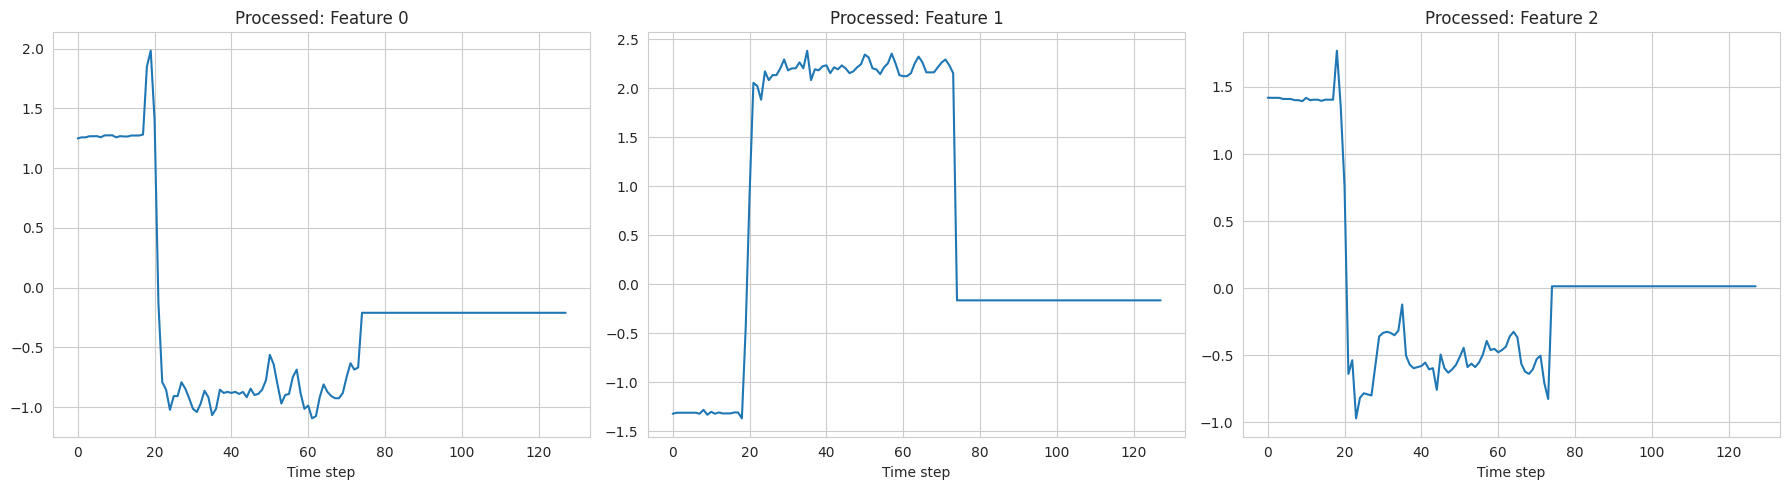

In [9]:
# 前処理後データから同じsubject/sequence_idのウィンドウを抽出
info_df = pd.DataFrame(train_info)
target_windows_idx = info_df[info_df['sequence_id'] == sample_seq].index.tolist()

print(f"Found {len(target_windows_idx)} windows for sequence_id {sample_seq}")

# 例として最初のウィンドウを可視化
if target_windows_idx:
    idx = target_windows_idx[0]
    window = train_windows[idx]  # shape: (window_size, n_features)
    plt.figure(figsize=(18, 5))
    for i in range(min(3, window.shape[1])):
        plt.subplot(1, 3, i+1)
        plt.plot(window[:, i])
        plt.title(f"Processed: Feature {i}")
        plt.xlabel("Time step")
    plt.tight_layout()
    plt.show()

## 3. 補正内容の妥当性チェック例
- 利き手補正: handednessカラムで左右反転がなされているか
- NaN補間: 欠損値がどのように埋められたか
- 正規化: 平均0・標準偏差1になっているか

Handedness: 1


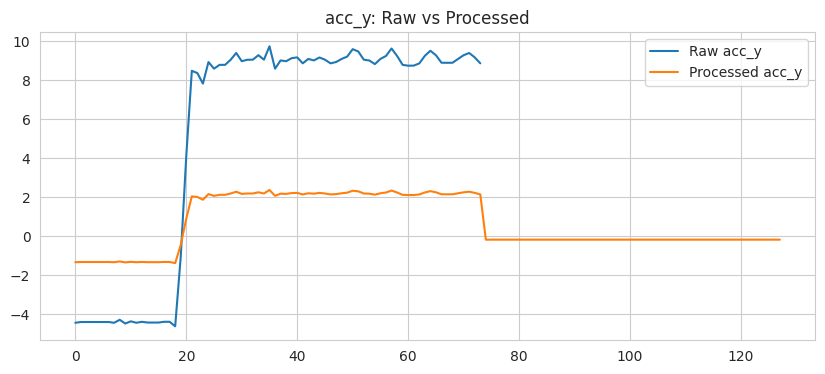

In [10]:
# 例: handedness補正前後の比較
if 'handedness' in sample_raw.columns:
    print("Handedness:", sample_raw['handedness'].iloc[0])
    # 例えばacc_y, acc_zが反転しているかを比較
    plt.figure(figsize=(10, 4))
    plt.plot(sample_raw['acc_y'].values, label='Raw acc_y')
    plt.plot(window[:, sensor_cols.index('acc_y')], label='Processed acc_y')
    plt.legend()
    plt.title('acc_y: Raw vs Processed')
    plt.show()